In [1]:
import datetime
import json
import re
import pathlib
import multiprocessing as mp
import xarray as xr
import tqdm
import random
import numpy.ma as ma
from scipy.interpolate import griddata

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from functools import partial
from dateutil.relativedelta import relativedelta

In [2]:
src_path = pathlib.Path("/gpfs/work2/0/prjs1027/swn-runs/02-2022/computations")
boundary_path = pathlib.Path(
    "/gpfs/work2/0/prjs1027/guus/data/BoundaryConditions/bnd.nc"
)
bathymetry_path = pathlib.Path('/gpfs/work2/0/prjs1027/swn-runs/02-2022/geometry/swan-ns-j22_6-v1a_adjust.bot')
write_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run3')
write_dir.mkdir(exist_ok=True, parents=True)
filtered_paths = [path for path in src_path.glob('ens*') if re.search(r'\d+$', str(path))]

boundary_ds = xr.open_dataset(boundary_path)

# %%
output_variables = ["hs", "theta0", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "wl", "xcur", "ycur"]
boundary_variables = ["hs", "hswe", "tmm10", "theta0"]
conversion_dict = {"hs": "Hm0", "hswe": "HE10", "tmm10": "Tmm10", "theta0": "meanD"}

random.seed(42)

In [36]:
xr.open_dataset(write_dir / 'min-max-values/min-max-values-all.nc')['xwnd'].values

array([-28.12585831,  33.2987442 ])

In [25]:
def to_mag_and_dir(x_component, y_component):
    mag = np.sqrt(x_component**2 + y_component**2)

    dir = np.arctan2(y_component, x_component)
    dir = dir % (2 * np.pi)
    return mag, dir

In [21]:
ds = xr.open_dataset(ens_datasets[0])
ds

<xarray.Dataset>
Dimensions:    (time: 13, longitude: 421, latitude: 481)
Coordinates:
  * time       (time) datetime64[ns] 2022-01-01 ... 2022-01-04
  * longitude  (longitude) float32 -12.0 -11.95 -11.9 -11.85 ... 8.9 8.95 9.0
  * latitude   (latitude) float32 48.0 48.03 48.07 48.1 ... 63.93 63.97 64.0
Data variables:
    hs         (time, latitude, longitude) float32 ...
    hswe       (time, latitude, longitude) float32 ...
    tmm10      (time, latitude, longitude) float32 ...
    tps        (time, latitude, longitude) float32 ...
    theta0     (time, latitude, longitude) float32 ...
    fdir       (time, latitude, longitude) float32 ...
    spread     (time, latitude, longitude) float32 ...
    ssh        (time, latitude, longitude) float32 ...
    xcur       (time, latitude, longitude) float32 ...
    ycur       (time, latitude, longitude) float32 ...
    xwnd       (time, latitude, longitude) float32 ...
    ywnd       (time, latitude, longitude) float32 ...
Attributes:
    Conventions:             CF-1.5
    History:                 Created with agioncmd version 1.5
    Directional_convention:  nautical
    project:                 SWAN-EPS
    run:                     028

In [31]:
mag, dir = to_mag_and_dir(ds['xcur'].values[0, ...], ds['ycur'].values[0, ...])

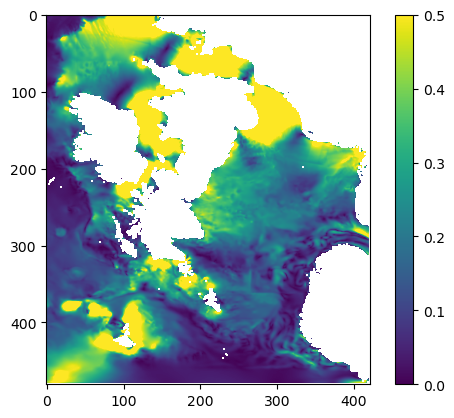

In [35]:
plt.imshow(mag, vmax=0.5)
plt.colorbar()

In [3]:
def load_ascii_bathy(input_grid_file_path, lon_start, lat_start, lon_step, lat_step):
    """
    Loads bathymetry and grid from ascii file (GEBCO)
 
    Args:
        input_grid_file_path (str): path to grid file
        lon_start: start longitude
        lat_start:
    Returns:
        lon, lat, bottom_data (np.array): 2D arrays with lon and lat values
        and bottom data
 
    Example usage:
        lon_start, lat_start, lon_step, lat_step = -3.000000, 51.500000, 0.500000, 0.500000
        lon_bathy, lat_bathy, bottom_data = input_loader.load_bathy(extra_path + "depth.GRD", lon_start, lat_start, lon_step, lat_step)
 
    """
    # Read the bottom grid data from the ASCII file
    bottom_data = np.loadtxt(input_grid_file_path)
 
    # Transpose the data to match the provided organization (latitude columns, longitude rows)
    bottom_data = bottom_data.T
 
    # Replace -999 with NaN
    bottom_data[bottom_data == -999] = np.nan
 
    lons = np.arange(lon_start, lon_start + len(bottom_data[0]) * lon_step, lon_step)
    lats = np.arange(lat_start, lat_start + len(bottom_data) * lat_step, lat_step)
 
    # Create a meshgrid from the coordinates
    lon, lat = np.meshgrid(lons, lats)
 
    return lon, lat, bottom_data

In [18]:
bathymetry = load_ascii_bathy(bathymetry_path, -12, 48, 0.05, 1/30)[2]

ens_datasets = list(filtered_paths[0].glob('*/output/*.nc'))
ens_datasets.sort()

In [11]:
import copy
bathymetry_mask = copy.deepcopy(bathymetry)
bathymetry_mask[np.isnan(bathymetry)] = 0
bathymetry_mask[~np.isnan(bathymetry)] = 1

np.save(write_dir / 'valid-mask.npy', bathymetry_mask)

In [37]:
np.load(write_dir / 'valid-mask.npy').shape

(481, 421)

In [5]:
def create_time_blocks(start_date, end_date, block_duration, block_gap):
    blocks = []
    current_start = start_date

    while current_start + block_duration <= end_date:
        current_end = current_start + block_duration
        blocks.append(slice(current_start, current_end))
        current_start = current_end + block_gap
    return blocks

In [38]:
tf.boolean_mask(ds['xwnd'], bathymetry_mask)

2025-04-15 09:32:47.766713: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-04-15 09:32:47.766806: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn286.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist


ValueError: Shapes (13, 481) and (481, 421) are incompatible

In [6]:
# Define the start and end dates
start_date = datetime.datetime(2022, 1, 1)
end_date = datetime.datetime(2023, 1, 1)

# Define the block duration (2 weeks) and break duration (12 hours)
block_duration = datetime.timedelta(weeks=2)
break_duration = datetime.timedelta(hours=12)

In [7]:
time_blocks = create_time_blocks(start_date, end_date, block_duration, break_duration)
random.shuffle(time_blocks)

In [8]:
n_train_blocks = np.floor(0.7 * len(time_blocks)).astype(np.int32)
n_val_blocks = np.ceil(0.15 * len(time_blocks)).astype(np.int32)
n_test_blocks = np.ceil(0.15 * len(time_blocks)).astype(np.int32)

train_blocks = time_blocks[:n_train_blocks]
val_blocks = time_blocks[n_train_blocks:(n_train_blocks + n_val_blocks)]
test_blocks = time_blocks[(n_train_blocks + n_val_blocks):]

In [9]:
def correct_nan_theta0(ds):
    for i in range(ds.time.shape[0]):
        hs = ds['hs'].values[i, ...]
        theta0 = ds['theta0'].values[i, ...]
        mask_hs = ma.masked_invalid(hs).mask
        mask_theta0 = ma.masked_invalid(theta0).mask
        
        invalid_ns_mask = np.logical_xor(mask_hs, mask_theta0)
        if invalid_ns_mask.sum() > 0:
            # Extract valid data points
            x = np.arange(theta0.shape[1])
            y = np.arange(theta0.shape[0])
            
            xx, yy = np.meshgrid(x, y)
            x1 = xx[~invalid_ns_mask]
            y1 = yy[~invalid_ns_mask]
            
            new_data = theta0[~invalid_ns_mask]
                    
            # Create interpolator for valid data
            interpolated = griddata((x1, y1), new_data.ravel(), (xx, yy), method='nearest', fill_value=None)
            ds['theta0'].values[i, ...] = interpolated
    return ds

def correct_outlier_cur(ds):
    for i in range(ds.time.shape[0]):
        xcur = ds['xcur'].values[i, ...]
        ycur = ds['ycur'].values[i, ...]
        
        outliers_xcur = np.abs(xcur) > 3
        outliers_ycur = np.abs(ycur) > 3
        
        x = np.arange(xcur.shape[1])
        y = np.arange(xcur.shape[0])

        xx, yy = np.meshgrid(x, y)
        x1_xcur = xx[~outliers_xcur]
        y1_xcur = yy[~outliers_xcur]

        x1_ycur = xx[~outliers_ycur]
        y1_ycur = yy[~outliers_ycur]

        new_xcur = xcur[~outliers_xcur]
        new_ycur = ycur[~outliers_ycur]

        interpolated_xcur = griddata((x1_xcur, y1_xcur), new_xcur.ravel(), (xx, yy), method='nearest', fill_value=None)
        interpolated_ycur = griddata((x1_ycur, y1_ycur), new_ycur.ravel(), (xx, yy), method='nearest', fill_value=None)
        
        ds['xcur'].values[i, ...] = interpolated_xcur
        ds['ycur'].values[i, ...] = interpolated_ycur

    return ds
        

In [10]:
def gather_input(path, boundary_ds, input_variables, output_variables, boundary_variables, time_chunks):
    variables = input_variables + output_variables
    
    input_fields = {}
    input_fields = {var: [] for var in variables}
    boundary_fields = {var: [] for var in boundary_variables}
    for _ in tqdm.tqdm(list(path.glob("*"))):
        try:
            ds_path = next(_.glob("output/*.nc"))
            ds = xr.open_dataset(ds_path)
        except:
            # print(f"{_ / 'output/swan2d.nc'} does not exist, skipping")
            continue

        for time_block in time_chunks:
            ds_sel = ds.sel({'time': time_block})
            
            if ds_sel.time.shape[0] <= 2:
                continue
                
            ds_sel['wl'] = ds_sel['ssh'] + bathymetry
            ds_sel = correct_nan_theta0(ds_sel)
            ds_sel = correct_outlier_cur(ds_sel)
            for var in variables:
                data = ds_sel[var].values
                shapes = data.shape

                if var in input_variables:
                    combined_fields = np.empty((shapes[0] - 2, shapes[1], shapes[2], 3))
                    for t in range(2, shapes[0]):
                        combined_fields[t - 2, ..., 0] = data[t - 2, ...]
                        combined_fields[t - 2, ..., 1] = data[t - 1, ...]
                        combined_fields[t - 2, ..., 2] = data[t, ...]
                elif var in output_variables:
                    combined_fields = np.empty((shapes[0] - 2, shapes[1], shapes[2], 1))
                    for t in range(2, shapes[0]):
                        combined_fields[t - 2, ..., 0] = data[t, ...]
                        
                        if var in list(boundary_fields.keys()):
                            boundary_field = (
                                boundary_ds[conversion_dict[var]].sel(time=ds_sel.time[t]).values
                            )
                            boundary_field = boundary_field.reshape(
                                (1, boundary_field.shape[0])
                            )
                            boundary_fields[var].append(boundary_field.astype(np.float32))
                input_fields[var].append(combined_fields.astype(np.float32))

    # Concatenate all the arrays for each variable
    for var in variables:
        input_fields[var] = np.concatenate(input_fields[var], axis=0)
        if var in list(boundary_fields.keys()):
            boundary_fields[var] = np.concatenate(boundary_fields[var], axis=0)

    print(f"Done with {path}")
    return input_fields, boundary_fields

In [11]:
# %%
def get_files(data_path):
    files = tf.io.gfile.glob(data_path + "/" + "*.tfrecords")
    return files


def get_dataset(files):
    """return a tfrecord dataset with all tfrecord files"""
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(tf_parse)
    return dataset


def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    if isinstance(value, type(tf.constant(0))):
        # BytesList won't unpack a string from an EagerTensor.
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


def _float_feature(value):
    """Returns a float_list from a float / double."""
    return tf.train.Feature(float_list=tf.train.FloatList(value=[value]))


def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))


def serialize_array(array):
    array = tf.io.serialize_tensor(array)
    return array


def parse_combined_data(variables):
    # define the dictionary -- the structure -- of our single example
    var = list(variables.keys())[0]
    data = {
        "height": _int64_feature(variables[var].shape[0]),
        "width": _int64_feature(variables[var].shape[1]),
        "depth": _int64_feature(variables[var].shape[2]),
    }

    # define dictionary for each mode
    for var in variables.keys():
        data[var] = _bytes_feature(serialize_array(variables[var]))

    out = tf.train.Example(features=tf.train.Features(feature=data))

    return out


def write_data(variables, filename, max_files, out_dir):
    """Writes the data to multiple tfrecord files each containing max_files examples"""
    try:
        filename = filename.stem
    except:
        pass
    var = list(variables.keys())[0]
    splits = (len(variables[var]) // max_files) + 1
    if len(variables[var]) % max_files == 0:
        splits -= 1

    print(
        f"\nUsing {splits} shard(s) for {len(variables[var])} files,\
            with up to {max_files} samples per shard"
    )

    file_count = 0

    for i in tqdm.tqdm(range(splits)):
        if i == splits - 1 and len(variables[var]) % max_files != 0:
            current_shard_name = "{}{}_{}_{}_{}.tfrecords".format(
                out_dir, i + 1, splits, filename, len(variables[var]) % max_files
            )
        else:
            current_shard_name = "{}{}_{}_{}_{}.tfrecords".format(
                out_dir, i + 1, splits, filename, max_files
            )

	# options = tf.io.TFRecordOptions(compression_type="ZLIB")
        writer = tf.io.TFRecordWriter(current_shard_name)#, options=options)

        current_shard_count = 0
        while current_shard_count < max_files:
            index = i * max_files + current_shard_count
            if index == len(variables[var]):
                break

            current_variables = {}
            for key in variables.keys():
                current_variables[key] = variables[key][index]

            out = parse_combined_data(current_variables)

            writer.write(out.SerializeToString())
            current_shard_count += 1
            file_count += 1

        writer.close()

    print(f"\nWrote {file_count} elements to TFRecord")
    return file_count


def get_dataset_large(
    tfr_dir=str(write_dir) + "train_data/", pattern: str = "*train_data.tfrecords"
):
    """Loads the tfrecord files and returns a tfrecord dataset"""
    files = glob.glob(tfr_dir + pattern, recursive=False)

    dataset = tf.data.TFRecordDataset(files)

    dataset = dataset.map(tf_parse)

    return dataset


def tf_parse(eg):
    """parse an example (or batch of examples, not quite sure...)"""

    # here we re-specify our format
    # you can also infer the format from the data using tf.train.Example.FromString
    # but that did not work
    vars = variable_fields
    parse_dict = {
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "depth": tf.io.FixedLenFeature([], tf.int64),
    }

    for var in vars:
        parse_dict[var] = tf.io.FixedLenFeature([], tf.string)

    example = tf.io.parse_example(
        eg[tf.newaxis],
        parse_dict,
    )
    hs = tf.io.parse_tensor(example["hs"][0], out_type="float32")
    hs_bnd = tf.io.parse_tensor(example["hs_bnd"][0], out_type="float32")
    # inputs = tf.io.parse_tensor(example["inputs"][0], out_type="float64")
    # outputs = tf.io.parse_tensor(example["outputs"][0], out_type="float64")
    return hs, hs_bnd


# %%
# Define the function to process each path
def process_path(path, time_chunks, write_dir):
    variable_fields, boundary_fields = gather_input(
        path,
        boundary_ds=boundary_ds,
        input_variables=input_variables,
        output_variables=output_variables,
        boundary_variables=boundary_variables,
        time_chunks=time_chunks
    )
    for var in boundary_variables:
        variable_fields[f"{var}_bnd"] = boundary_fields[var]

    write_dir.mkdir(exist_ok=True, parents=True)
    write_data(
        variables=variable_fields,
        filename=path,
        max_files=10,
        out_dir=str(write_dir) + "/",
    )
    print(f"Processed {path}")

In [12]:
process_path(filtered_paths[0], time_chunks=val_blocks, write_dir=write_dir / 'val_data')

100%|██████████| 364/364 [10:34<00:00,  1.74s/it]


Done with /gpfs/work2/0/prjs1027/swn-runs/02-2022/computations/ens28

Using 61 shard(s) for 606 files,            with up to 10 samples per shard


  0%|          | 0/61 [00:00<?, ?it/s]


NotFoundError: /gpfs/work2/0/prjs1027/tfrecords/run3/val_data/1_61_ens28_10.tfrecords; No such file or directory

In [41]:
ds = xr.open_dataset(ens_datasets[0])

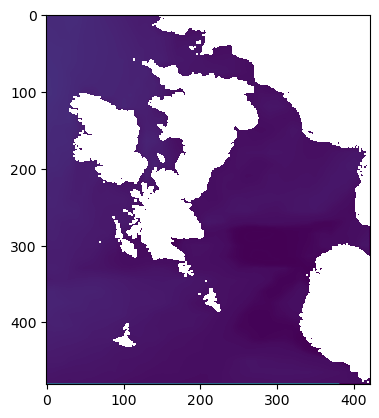

In [42]:
fig, ax = plt.subplots()
ax.imshow(ds['hs'].values[0, ...])

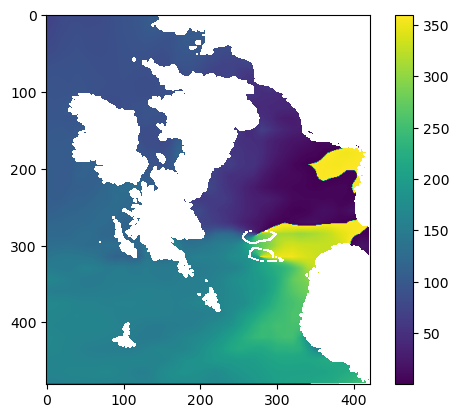

In [43]:
fig, ax = plt.subplots()
plt.imshow(ds['theta0'].values[0, ...])
plt.colorbar()

In [44]:
hs = ds['hs'].values[0, ...]
theta0 = ds['theta0'].values[0, ...]
mask = ma.masked_invalid(hs).mask
mask_theta0 = ma.masked_invalid(theta0).mask

invalid_ns_mask = np.logical_xor(mask, mask_theta0)

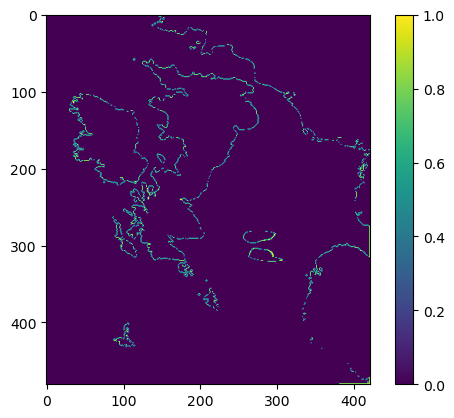

In [45]:
plt.imshow(np.logical_xor(mask, mask_theta0))
plt.colorbar()

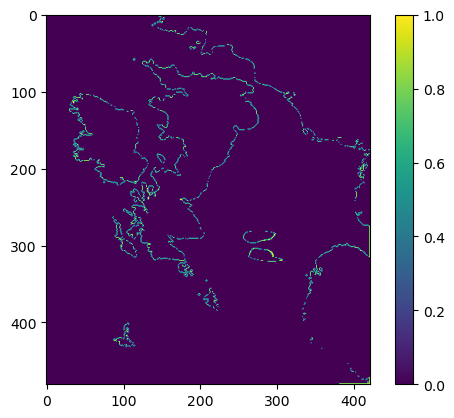

In [46]:
plt.imshow(mask_theta0.astype(np.int32) - mask.astype(np.int32))
plt.colorbar()

In [57]:
from scipy.interpolate import griddata
# Extract valid data points
data = ds['theta0'].values[0, ...]

x = np.arange(data.shape[1])
y = np.arange(data.shape[0])

xx, yy = np.meshgrid(x, y)
x1 = xx[~invalid_ns_mask]
y1 = yy[~invalid_ns_mask]

new_data = data[~invalid_ns_mask]


# Create interpolator for valid data
interpolator = griddata((x1, y1), new_data.ravel(), (xx, yy), method='nearest', fill_value=None)


# points = np.where(invalid_ns_mask)

interp = interpolator(points)
# data[invalid_ns_mask] = interp

TypeError: 'numpy.ndarray' object is not callable

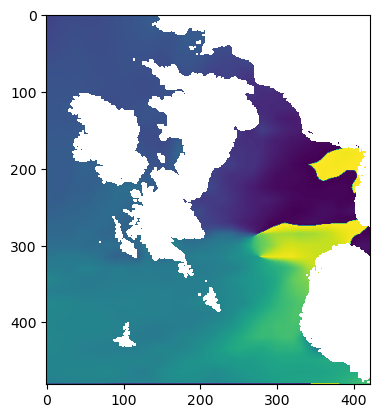

In [58]:
plt.imshow(interpolator)

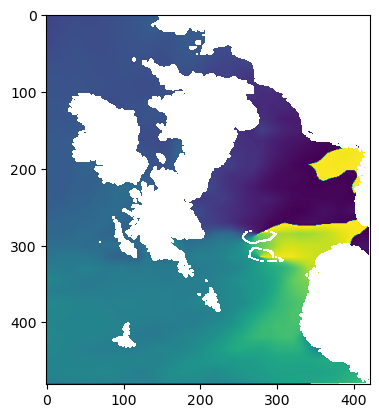

In [59]:
plt.imshow(data)

In [64]:
theta_masker = ma.masked_invalid(ds['theta0'].values).mask

In [87]:
i = 10
hs_1 = ds['hs'].values[i, ...]
theta0_1 = ds['theta0'].values[i, ...]
mask_1 = ma.masked_invalid(hs_1).mask
mask_theta0_1 = ma.masked_invalid(theta0_1).mask

invalid_ns_mask_1 = np.logical_xor(mask_1, mask_theta0_1)

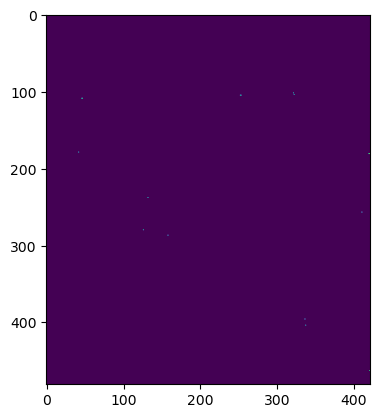

In [88]:
plt.imshow(invalid_ns_mask_1)

In [89]:
invalid_ns_mask_1.sum()

16

In [124]:
ds_new = correct_outlier_cur(ds)

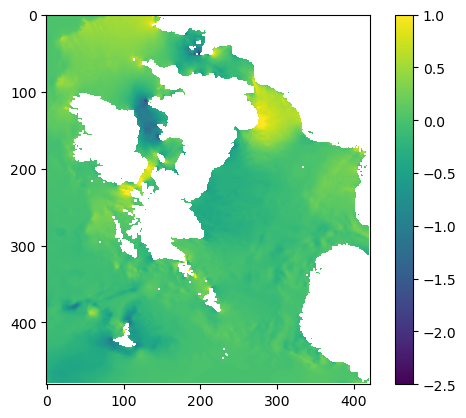

In [132]:
plt.imshow(ds['ycur'].values[0, ...], vmin=-2.5, vmax=1) 
plt.colorbar()

In [128]:
np.nanquantile(ds_new['xcur'].values[...], 1)

2.8547013

In [117]:
xcur = ds['xcur'].values[...] 
xcur[np.abs(xcur) > 3]

array([ -3.6860256,  -5.2125616, -11.753288 ,  -5.2058473, -11.606189 ,
       -17.323526 , -18.753624 ,  14.775842 , -10.302439 ,  -5.800348 ,
         3.028657 , -11.62328  , -17.323526 , -18.755455 ,  14.775231 ,
       -11.735588 ,  -5.12833  , -11.644643 , -17.323526 , -18.753624 ,
        14.775842 , -10.351268 ,  -5.7203894,   3.0890834, -11.6318245,
       -17.323526 , -18.754234 ,  14.775231 ,  -3.0390332, -11.735588 ,
        -5.007477 , -11.697134 , -17.323526 , -18.753014 ,  14.775231 ,
       -10.401929 ,  -5.432295 ,  -5.8833585, -11.615345 , -17.323526 ,
       -18.754845 ,  14.775842 , -11.754509 ,  -4.88052  , -11.725211 ,
       -17.323526 , -18.753014 ,  14.775231 , -10.431227 ,  -5.4499955,
        -5.8717613, -11.581164 , -17.323526 , -18.754845 ,  14.775231 ,
       -11.786859 ,  -4.8744164, -11.7606125, -17.323526 , -18.753624 ,
        14.775842 ,  -4.555193 , -10.481887 ,  -5.480514 ,  -5.96881  ,
       -11.569567 , -17.323526 , -18.754845 ,  14.775231 ,  -3.1

In [18]:
38 * 25

950